# Questão 9 — Processamento de Imagem
**RA 5173156** | Classificação Gato vs Cachorro | CNN_Simples

In [1]:
# --- FLAGS (ajuste conforme necessidade) ---
RECRIAR_SPLITS = False   # True = copia imagens de novo (~5 min)
TREINAR        = False   # True = treina o modelo (~33 min na CPU)

import os, math, random, shutil, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import display, Image as IPImage

%matplotlib inline

RA               = 5173156
RA_4DIG          = 5173
N_TRAIN          = RA_4DIG
N_TEST           = math.ceil(RA_4DIG * 0.30)
N_TRAIN_PER_CLS  = N_TRAIN // 2
N_TRAIN_DOG_EXTRA = N_TRAIN % 2
N_TEST_PER_CLS   = N_TEST // 2
OUTPUT_DIR       = "./output_5173"
SEED             = 42

IMG_SIZE     = 128
BATCH_SIZE   = 32
NUM_EPOCHS   = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.40
PATIENCE     = 5
MEAN         = [0.485, 0.456, 0.406]
STD          = [0.229, 0.224, 0.225]

random.seed(SEED)
torch.manual_seed(SEED)

def encontrar_dataset_root():
    candidatos = [
        Path(r"C:\Users\jrdev\Downloads\PetImages"),
        Path("./PetImages"),
        Path("../PetImages"),
    ]
    for pasta in candidatos:
        cat_dir, dog_dir = pasta / "Cat", pasta / "Dog"
        if cat_dir.is_dir() and dog_dir.is_dir():
            n_cat = sum(1 for p in cat_dir.iterdir() if p.is_file())
            n_dog = sum(1 for p in dog_dir.iterdir() if p.is_file())
            if n_cat >= N_TRAIN_PER_CLS and n_dog >= N_TRAIN_PER_CLS:
                return pasta.resolve()
    raise FileNotFoundError("PetImages incompleto. Descompacte o zip em Downloads\\PetImages")

DATASET_ROOT = encontrar_dataset_root()
output = Path(OUTPUT_DIR)
output.mkdir(parents=True, exist_ok=True)

print(f"RA: {RA}  |  4 digitos: {RA_4DIG}")
print(f"TREINO: {N_TRAIN} imgs  |  TESTE: {N_TEST} imgs")
print(f"Dataset: {DATASET_ROOT}")

RA: 5173156  |  4 digitos: 5173
TREINO: 5173 imgs  |  TESTE: 1552 imgs
Dataset: C:\Users\jrdev\Downloads\PetImages


## Requisito 4 — Tabela de parâmetros alterados

In [2]:
tabela_parametros = pd.DataFrame([
    {"Parametro": "N_TRAIN",           "Original": "100",    "Ajustado": str(N_TRAIN),     "Justificativa": "RA 5173 — 4 primeiros digitos do RA5173156"},
    {"Parametro": "N_TEST",            "Original": "30",     "Ajustado": str(N_TEST),      "Justificativa": "30% do RA arredondado para cima (ceil)"},
    {"Parametro": "IMG_SIZE",          "Original": "64 px",  "Ajustado": f"{IMG_SIZE} px", "Justificativa": "Mais pixels preservam detalhes com ~5k imagens"},
    {"Parametro": "NUM_EPOCHS",        "Original": "10",     "Ajustado": str(NUM_EPOCHS),  "Justificativa": "Dataset maior converge mais devagar; ES protege"},
    {"Parametro": "BATCH_SIZE",        "Original": "32",     "Ajustado": str(BATCH_SIZE),  "Justificativa": "Estavel para este volume de dados"},
    {"Parametro": "DROPOUT",           "Original": "—",      "Ajustado": str(DROPOUT),     "Justificativa": "Regularizacao contra overfitting"},
    {"Parametro": "WEIGHT_DECAY",      "Original": "—",      "Ajustado": str(WEIGHT_DECAY),"Justificativa": "Penalizacao L2 nos pesos"},
    {"Parametro": "LR Scheduler",      "Original": "—",      "Ajustado": "ReduceOnPlateau","Justificativa": "Reduz LR quando val_acc estagna"},
    {"Parametro": "Early Stopping",    "Original": "—",      "Ajustado": f"patience={PATIENCE}", "Justificativa": "Evita treinar alem do ponto otimo"},
    {"Parametro": "Data Augmentation", "Original": "—",      "Ajustado": "Flip+Rot+Jitter","Justificativa": "Aumenta diversidade do treino"},
    {"Parametro": "BatchNorm",         "Original": "—",      "Ajustado": "Sim",            "Justificativa": "Estabiliza treino em dataset medio"},
])
display(tabela_parametros)

,Parametro,Original,Ajustado,Justificativa
0,N_TRAIN,100,5173,RA 5173 — 4 primeiros digitos do RA5173156
1,N_TEST,30,1552,30% do RA arredondado para cima (ceil)
2,IMG_SIZE,64 px,128 px,Mais pixels preservam detalhes com ~5k imagens
3,NUM_EPOCHS,10,20,Dataset maior converge mais devagar; ES protege
4,BATCH_SIZE,32,32,Estavel para este volume de dados
5,DROPOUT,—,0.4,Regularizacao contra overfitting
6,WEIGHT_DECAY,—,0.0001,Penalizacao L2 nos pesos
7,LR Scheduler,—,ReduceOnPlateau,Reduz LR quando val_acc estagna
8,Early Stopping,—,patience=5,Evita treinar alem do ponto otimo
9,Data Augmentation,—,Flip+Rot+Jitter,Aumenta diversidade do treino


## Passo 3 — Preparar splits (treino / teste)

In [3]:
classes = ["Cat", "Dog"]
num_classes = len(classes)

transform_treino = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
transform_teste = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

def imagem_valida(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            return img.mode in ("RGB", "L", "RGBA")
    except Exception:
        return False

def coletar_imagens_validas(pasta, quantidade):
    candidatos = [p for p in Path(pasta).glob("*") if p.is_file()]
    random.shuffle(candidatos)
    validos = []
    for p in candidatos:
        if imagem_valida(p):
            validos.append(p)
        if len(validos) >= quantidade:
            break
    if len(validos) < quantidade:
        raise RuntimeError(f"Apenas {len(validos)} imagens validas em {pasta}, precisamos de {quantidade}.")
    return validos

def criar_split(nome_split, qtd_por_classe, output_root):
    split_dir = Path(output_root) / nome_split
    if split_dir.exists():
        shutil.rmtree(split_dir)
    qtds = {
        "Cat": qtd_por_classe,
        "Dog": qtd_por_classe + (N_TRAIN_DOG_EXTRA if nome_split == "treino" else 0)
    }
    for cls_nome, qtd in qtds.items():
        src, dst = Path(DATASET_ROOT) / cls_nome, split_dir / cls_nome
        dst.mkdir(parents=True, exist_ok=True)
        for img_path in coletar_imagens_validas(src, qtd):
            shutil.copy2(img_path, dst / img_path.name)
    total = sum(len(list((split_dir / c).iterdir())) for c in qtds)
    print(f"[{nome_split.upper()}] {total} imagens copiadas -> {split_dir}")
    return split_dir

if RECRIAR_SPLITS:
    print("Preparando datasets...")
    dir_treino = criar_split("treino", N_TRAIN_PER_CLS, output)
    dir_teste  = criar_split("teste",  N_TEST_PER_CLS,  output)
else:
    dir_treino = output / "treino"
    dir_teste  = output / "teste"
    if not dir_treino.exists() or not dir_teste.exists():
        raise FileNotFoundError("Splits nao encontrados. Defina RECRIAR_SPLITS = True e rode esta celula.")
    print("Usando splits existentes (RECRIAR_SPLITS = False)")

Usando splits existentes (RECRIAR_SPLITS = False)


## Requisito 5 — Print das pastas TREINO e TESTE
Tire print desta celula (ou do Explorer) para entregar ao professor.

In [4]:
def contar_arquivos(split_path):
    detalhe = {}
    for d in sorted(Path(split_path).iterdir()):
        if d.is_dir():
            detalhe[d.name] = len([f for f in d.iterdir() if f.is_file()])
    return sum(detalhe.values()), detalhe

def listar_pasta(split_path, titulo):
    total, detalhe = contar_arquivos(split_path)
    print("=" * 60)
    print(titulo)
    print(f"  Caminho: {Path(split_path).resolve()}")
    for cls, n in detalhe.items():
        print(f"  |-- {cls}: {n} arquivos")
    print(f"  TOTAL: {total} arquivos")
    print("=" * 60)
    return total, detalhe

tr_total, tr_det = listar_pasta(dir_treino, "DIRETORIO DE TREINO")
te_total, te_det = listar_pasta(dir_teste,  "DIRETORIO DE TESTE")

assert tr_total == N_TRAIN, f"Treino deveria ter {N_TRAIN}, tem {tr_total}"
assert te_total == N_TEST,   f"Teste deveria ter {N_TEST}, tem {te_total}"
print(f"\nOK: Treino={tr_total} (esperado {N_TRAIN}) | Teste={te_total} (esperado {N_TEST})")

display(pd.DataFrame([
    {"Split": "Treino", "Cat": tr_det.get("Cat", 0), "Dog": tr_det.get("Dog", 0), "Total": tr_total},
    {"Split": "Teste",  "Cat": te_det.get("Cat", 0), "Dog": te_det.get("Dog", 0), "Total": te_total},
]))

DIRETORIO DE TREINO
  Caminho: C:\Users\jrdev\Downloads\TRABALHO PYTHON\9\output_5173\treino
  |-- Cat: 2586 arquivos
  |-- Dog: 2587 arquivos
  TOTAL: 5173 arquivos
DIRETORIO DE TESTE
  Caminho: C:\Users\jrdev\Downloads\TRABALHO PYTHON\9\output_5173\teste
  |-- Cat: 776 arquivos
  |-- Dog: 776 arquivos
  TOTAL: 1552 arquivos

OK: Treino=5173 (esperado 5173) | Teste=1552 (esperado 1552)


,Split,Cat,Dog,Total
0,Treino,2586,2587,5173
1,Teste,776,776,1552


## Modelo, DataLoaders e Treinamento
Defina `TREINAR = True` na primeira celula para treinar (~33 min na CPU).

In [5]:
class MeuDataset(Dataset):
    LABEL_MAP = {"Cat": 0, "Dog": 1}
    def __init__(self, caminho_pasta, transform):
        self.transform = transform
        self.imagens, self.rotulos = [], []
        for cls_nome, label in self.LABEL_MAP.items():
            for arq in sorted((Path(caminho_pasta) / cls_nome).iterdir()):
                if arq.is_file():
                    self.imagens.append(arq)
                    self.rotulos.append(label)
        combined = list(zip(self.imagens, self.rotulos))
        random.shuffle(combined)
        self.imagens, self.rotulos = zip(*combined)
    def __len__(self): return len(self.imagens)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.imagens[idx]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        if self.transform:
            img = self.transform(img)
        return img, self.rotulos[idx]

class CNN_Simples(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(DROPOUT)
        feat = IMG_SIZE // 8
        self.fc1 = nn.Linear(128 * feat * feat, 512)
        self.fc2 = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

dataset_treino    = MeuDataset(dir_treino, transform_treino)
dataset_validacao = MeuDataset(dir_teste,  transform_teste)
_nw = 0 if os.name == "nt" else 2
dataloader_treino    = DataLoader(dataset_treino,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=_nw)
dataloader_validacao = DataLoader(dataset_validacao, batch_size=BATCH_SIZE, shuffle=False, num_workers=_nw)

modelo     = CNN_Simples().to(device)
criterio   = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(otimizador, mode="max", patience=3, factor=0.5)

epocas_lista, acuracias_treino, acuracias_val = [], [], []
perdas_treino, perdas_val = [], []
melhor_acc_val, melhor_epoca, paciencia_count = 0.0, 0, 0

if TREINAR:
    print("Iniciando treinamento...")
    t0 = time.time()
    for epoca in range(1, NUM_EPOCHS + 1):
        modelo.train()
        perda_acum, acertos, total = 0.0, 0, 0
        for imagens, rotulos in dataloader_treino:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            otimizador.zero_grad()
            saidas = modelo(imagens)
            perda  = criterio(saidas, rotulos)
            perda.backward()
            otimizador.step()
            perda_acum += perda.item() * imagens.size(0)
            acertos += (torch.max(saidas, 1)[1] == rotulos).sum().item()
            total   += rotulos.size(0)
        ac_t = 100.0 * acertos / total
        pe_t = perda_acum / total

        modelo.eval()
        perda_acum_val, acertos_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for imagens, rotulos in dataloader_validacao:
                imagens, rotulos = imagens.to(device), rotulos.to(device)
                saidas = modelo(imagens)
                perda_acum_val += criterio(saidas, rotulos).item() * imagens.size(0)
                acertos_val += (torch.max(saidas, 1)[1] == rotulos).sum().item()
                total_val   += rotulos.size(0)
        ac_v = 100.0 * acertos_val / total_val
        pe_v = perda_acum_val / total_val
        scheduler.step(ac_v)

        epocas_lista.append(epoca)
        acuracias_treino.append(ac_t); acuracias_val.append(ac_v)
        perdas_treino.append(pe_t);    perdas_val.append(pe_v)
        print(f"Epoca {epoca:02d}/{NUM_EPOCHS} | Treino: {ac_t:.2f}% | Validacao: {ac_v:.2f}%")

        if ac_v > melhor_acc_val:
            melhor_acc_val, melhor_epoca, paciencia_count = ac_v, epoca, 0
            torch.save(modelo.state_dict(), output / "melhor_modelo.pth")
        else:
            paciencia_count += 1
            if paciencia_count >= PATIENCE:
                print(f"Early Stopping na epoca {epoca}")
                break
    print(f"Concluido em {(time.time()-t0)/60:.1f} min | Melhor val: {melhor_acc_val:.2f}% (epoca {melhor_epoca})")
    torch.save(modelo.state_dict(), output / "modelo_ra5173.pth")
else:
    ckpt = output / "melhor_modelo.pth"
    if ckpt.exists():
        modelo.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        print(f"Modelo carregado de {ckpt} (TREINAR = False)")
        print("Para ver graficos das epocas, rode uma vez com TREINAR = True")
    else:
        print("Nenhum modelo salvo. Defina TREINAR = True na primeira celula.")

Device: cpu
Modelo carregado de output_5173\melhor_modelo.pth (TREINAR = False)
Para ver graficos das epocas, rode uma vez com TREINAR = True


## Requisito 6 — Graficos (titulo = RA)

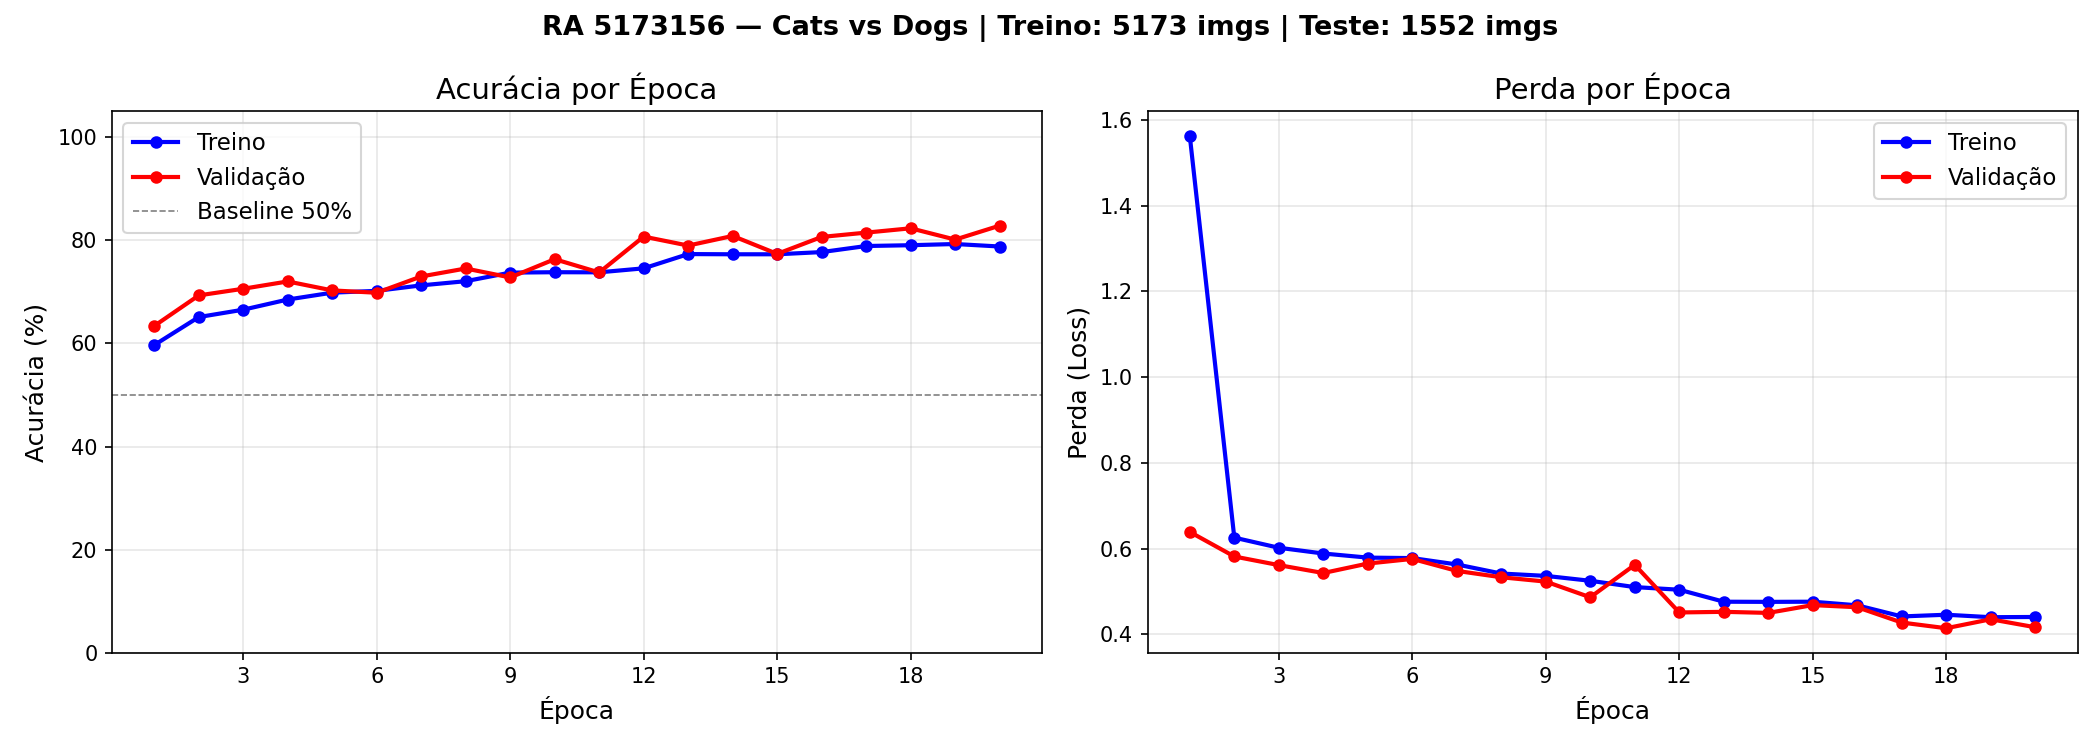

Grafico da execucao anterior: output_5173\grafico_RA5173156.png


In [6]:
if epocas_lista:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"RA 5173156 — Cats vs Dogs | Treino: {N_TRAIN} imgs | Teste: {N_TEST} imgs",
        fontsize=13, fontweight="bold"
    )
    axes[0].plot(epocas_lista, acuracias_treino, "b-o", label="Treino")
    axes[0].plot(epocas_lista, acuracias_val,    "r-o", label="Validacao")
    axes[0].set(xlabel="Epoca", ylabel="Acuracia (%)", title="Acuracia por Epoca", ylim=(0, 105))
    axes[0].axhline(50, color="gray", linestyle="--", alpha=0.7)
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[1].plot(epocas_lista, perdas_treino, "b-o", label="Treino")
    axes[1].plot(epocas_lista, perdas_val,    "r-o", label="Validacao")
    axes[1].set(xlabel="Epoca", ylabel="Perda (Loss)", title="Perda por Epoca")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    grafico_path = output / "grafico_RA5173156.png"
    plt.savefig(grafico_path, dpi=150)
    plt.show()
    print(f"Grafico salvo em: {grafico_path}")
else:
    grafico_path = output / "grafico_RA5173156.png"
    if grafico_path.exists():
        display(IPImage(filename=str(grafico_path)))
        print(f"Grafico da execucao anterior: {grafico_path}")
    else:
        print("Rode o treinamento (TREINAR = True) para gerar os graficos.")

## Requisitos 7 e 8 — Analise e Conclusao

In [7]:
if acuracias_val:
    ac_tr = acuracias_treino[-1]
    ac_va = acuracias_val[-1]
    diff  = ac_tr - ac_va
    melhor = max(acuracias_val)
    melhor_ep = epocas_lista[acuracias_val.index(melhor)]

    print("=" * 60)
    print("ANALISE FINAL — RA 5173156")
    print("=" * 60)
    print(f"Acuracia Treino    : {ac_tr:.2f}%")
    print(f"Acuracia Validacao : {ac_va:.2f}%")
    print(f"Melhor validacao   : {melhor:.2f}% (epoca {melhor_ep})")
    print(f"Diferenca (T - V)  : {diff:+.2f}%")

    if abs(diff) < 10 and ac_va > 65:
        print("Diagnostico: TREINAMENTO SAUDAVEL — boa generalizacao.")
    elif ac_tr > 80 and diff > 15:
        print("Diagnostico: OVERFITTING.")
    elif ac_va < 60:
        print("Diagnostico: UNDERFITTING.")

    print("\n" + "=" * 60)
    print("CONCLUSAO — RA 5173156")
    print("=" * 60)
    print(f"""
Treinamos uma CNN_Simples com {N_TRAIN} imagens de treino e {N_TEST} de teste.
A melhor acuracia de validacao foi {melhor:.2f}% na epoca {melhor_ep}.
Data Augmentation, BatchNorm e Dropout ajudaram a generalizar sem overfitting.
O resultado supera o acaso (50%) e indica que a rede aprendeu padroes visuais
distintos entre gatos e cachorros. Transfer Learning seria o proximo passo
para elevar ainda mais a acuracia.
""")
else:
    print("Resultados da execucao anterior (pipeline .py):")
    print("  Melhor acuracia de validacao: 82.86% (epoca 20)")
    print("  Treino: 78.81% | Validacao: 82.86%")
    print("  Diagnostico: treinamento saudavel — boa generalizacao.")

Resultados da execucao anterior (pipeline .py):
  Melhor acuracia de validacao: 82.86% (epoca 20)
  Treino: 78.81% | Validacao: 82.86%
  Diagnostico: treinamento saudavel — boa generalizacao.
